# Tutorial 3: Making Resonator Networks

The first two tutorials modelled a **single** resonator, but real chip designs rarely stop
there. Most involve several resonators coupled in a chain. For more complicated designs such as this, the process shown in Tutorial 1 can be 
repeated for multiple resonators in a network. This tutorial shows how to

1. **build** a network of many capacitors and multiple CPW resonators and look
   at its response,
2. **draw** that network with the schematics feature so you can see what you
   built, and
3. Fit a lumped oscillator model (LOM) to each resonator in the
   chain, reassemble the pieces, and check the lumped network against the CPW
   ground truth.

The device design we will use to test this is a chain of **three capacitively-coupled CPW resonators** with
*staggered lengths*, so each rings at its own frequency:

```
[P1] -- Cc1 -- Ctog -- CPW_1 -- Ctog -- Cc2 -- Ctog -- CPW_2 -- Ctog -- Cc3 -- Ctog -- CPW_3 -- Ctog -- Cc4 -- [P2]
```

A natural
"subgroup" of this larger design is one resonator with the two couplers and two ground caps that flank
it: `Cc -- Ctog -- CPW -- Ctog -- Cc`. That subgroup is exactly the topology
`fit_lom` already knows how to fit.


More complicated designs which include hanger resonators will be covered in Tutorials 8 and 9.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf

from simpleLOMs import CPWParams, fit_lom
from simpleLOMs.networks.cpw import cpw_resonator_network_2port
from simpleLOMs.networks.chain import resonator_chain_network_2port
from simpleLOMs.schematics import resonator_chain_schematic_2port
from simpleLOMs.analysis import circle_fit_f0_kappa, resonances_from_s_max

from simpleLOMs import (
    plot_transmission, plot_all_models, plot_re_im,
    apply_style, axis_label,
    COLOR_PRIMARY, COLOR_SECONDARY, COLOR_HIGHLIGHT,
    FIGURE_WIDTH_1COL, FIGURE_WIDTH_2COL,
    FIGURE_HEIGHT_1COL_GR, FIGURE_HEIGHT_2COL_GR,
)


apply_style()

cpw = CPWParams(ep_r=11.45)                        # ultracold-silicon substrate
freq = rf.Frequency(4e9, 12e9, 8_001, unit="Hz")  
Z0 = 50.0

# Three staggered CPW resonators 
lengths = [8.0e-3, 7.0e-3, 6.0e-3]                 # metres

# Four coupling capacitors 
Ccs = [8e-15, 6e-15, 6e-15, 8e-15]

Ctog = 1e-14
Ctogs = [Ctog] * (2 * len(lengths))

segments_cpw = [{"kind": "cpw", "d": d} for d in lengths]
print(f"{len(lengths)} CPW resonators, lengths (mm): {[d*1e3 for d in lengths]}")


3 CPW resonators, lengths (mm): [8.0, 7.0, 6.0]


## 1. Build the CPW network and look at it

Run `resonator_chain_network_2port` to wire the ladder together. Each entry
in `segments` is a resonator. Here every one is a CPW line (`{"kind": "cpw",
"d": ...}`), but in section 3 we will swap some for lumped `LC` tanks. `Ccs` holds
the coupling capacitors (one more than the number of resonators) and `Ctogs`
holds the ground capacitors (two per resonator).

In [3]:
chain_cpw = resonator_chain_network_2port(
    freq, segments_cpw, Ccs, Ctogs, cpw_params=cpw, Z0=Z0,
)



We then look at the network's transmission $|S_{21}|$ and
 reflection $|S_{11}|$. 

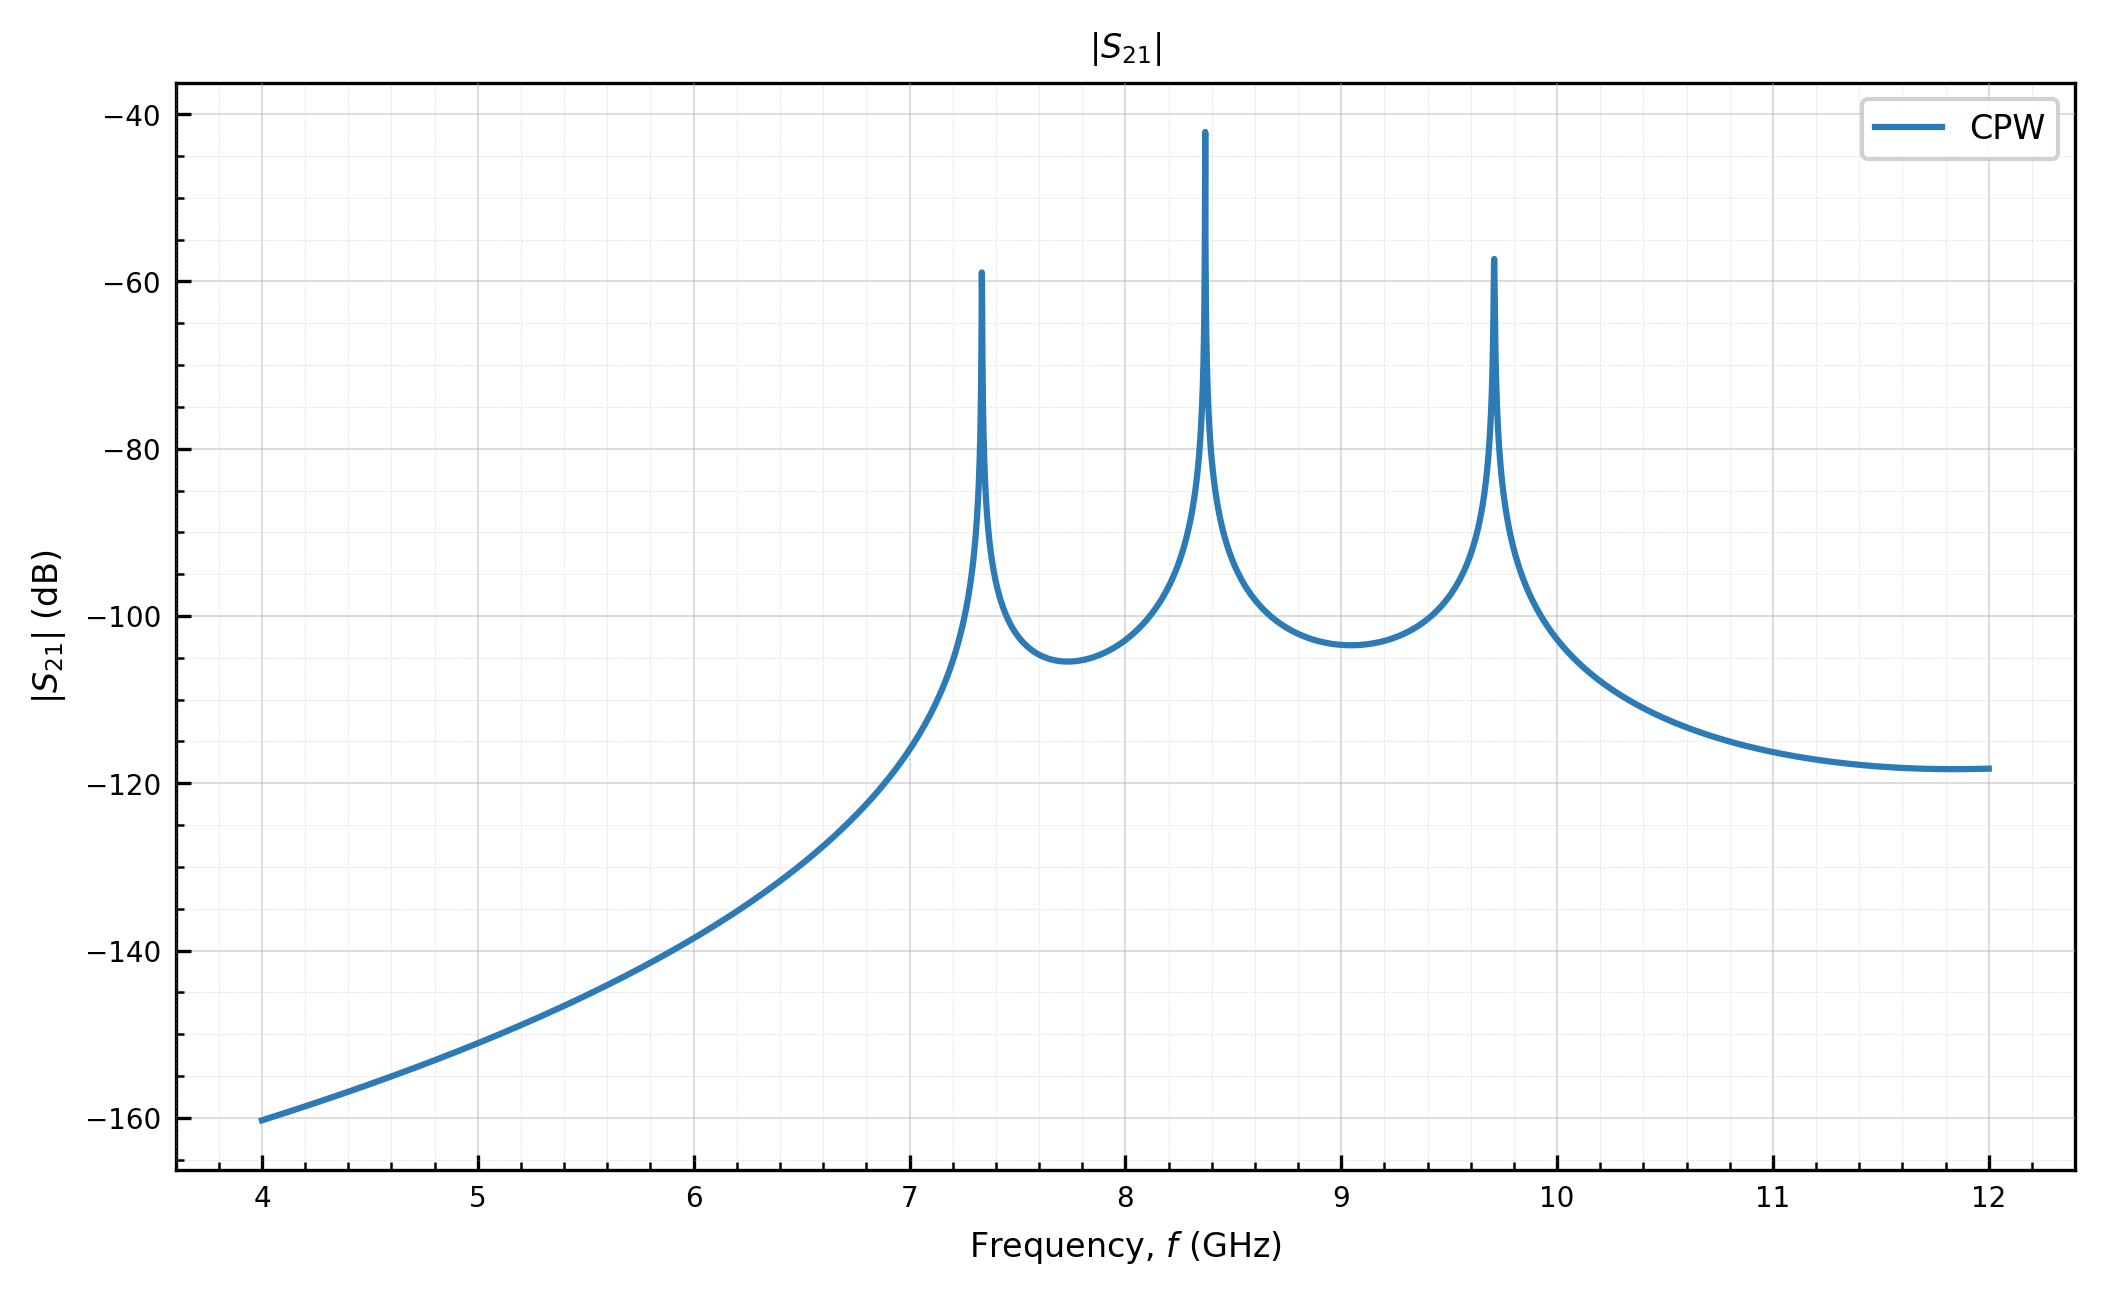

(<Figure size 2117.1x1308.44 with 1 Axes>,
 <Axes: title={'center': '$|S_{21}|$'}, xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>)

In [4]:
plot_transmission(
    {"CPW chain": chain_cpw},
    m=1, n=0,
)

The three modes can be read off from the S21 transmission peaks.

In [5]:

mode_freqs = resonances_from_s_max(chain_cpw, m=1, n=0)
mode_freqs = np.sort(mode_freqs)
print("Chain modes (GHz):", np.round(mode_freqs / 1e9, 4))


Chain modes (GHz): [7.335 8.37  9.709]


We have now constructed a full two-port network with the three distributed elements, which produce
three separate but coupled modes.


## 2. Draw the network with the schematics feature

To view the circuit you have just simulated, the `schematics` feature, using `resonator_chain_schematic_2port`, takes the same  
arguments as the network and returns a zoomable circuit diagram with every capacitance and line length labelled.

In [6]:
schematic_cpw = resonator_chain_schematic_2port(
    segments_cpw, Ccs, Ctogs,
    cpw_params=cpw, freq=freq, Z0=Z0,
    annotations={"resonators": len(lengths), "modes_GHz": list(np.round(mode_freqs / 1e9, 3))},
)

You can choose to save portable copies next to the notebook, and render them inline.

In [7]:

from pathlib import Path
figdir = Path("figures")
figdir.mkdir(exist_ok=True)
schematic_cpw.save_svg(figdir / "chain_cpw.svg")
schematic_cpw.save_html(figdir / "chain_cpw.html")
schematic_cpw


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.chain.resonator_chain_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'res1', 'label': 'resonator 1'}, {'id': 'res2', 'label': 'resonator 2'}, {'id': 'res3', 'label': 'resonator 3'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='Cc1', type='cap', label='C_{c1}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='Ctog1', type='cap', label='C_{tog1}', value='10.00 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'C': 1e-14}), Component(id='TL1', type='tline', label='CPW 1', value='\\ell = 8.00 mm', ports=['in', 'out'], group='res1', orient='series', props={'length': 0.008, 'Z0': 46.426279489739365}), Component(id='Ctog2', type='cap', label='C_{tog2}', value='10.00 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'C': 1e-14}), Component(id='Cc2', type='cap', label='C_{c2}', value='6.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 6e-15}), Component(id='Ctog3', type='cap', label='C_{tog3}', value='10.00 fF', ports=['a', 'gnd'], group='res2', orient='shunt', props={'C': 1e-14}), Component(id='TL2', type='tline', label='CPW 2', value='\\ell = 7.00 mm', ports=['in', 'out'], group='res2', orient='series', props={'length': 0.007, 'Z0': 46.426279489739365}), Component(id='Ctog4', type='cap', label='C_{tog4}', value='10.00 fF', ports=['a', 'gnd'], group='res2', orient='shunt', props={'C': 1e-14}), Component(id='Cc3', type='cap', label='C_{c3}', value='6.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 6e-15}), Component(id='Ctog5', type='cap', label='C_{tog5}', value='10.00 fF', ports=['a', 'gnd'], group='res3', orient='shunt', props={'C': 1e-14}), Component(id='TL3', type='tline', label='CPW 3', value='\\ell = 6.00 mm', ports=['in', 'out'], group='res3', orient='series', props={'length': 0.006, 'Z0': 46.426279489739365}), Component(id='Ctog6', type='cap', label='C_{tog6}', value='10.00 fF', ports=['a', 'gnd'], group='res3', orient='shunt', props={'C': 1e-14}), Component(id='Cc4', type='cap', label='C_{c4}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'Ctog1.a']), Net(id='n3', ports=['Ctog1.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'TL1.in']), Net(id='n5', ports=['TL1.out', 'Ctog2.a']), Net(id='n6', ports=['Ctog2.gnd', 'GND']), Net(id='n7', ports=['TL1.out', 'Cc2.a']), Net(id='n8', ports=['Cc2.b', 'Ctog3.a']), Net(id='n9', ports=['Ctog3.gnd', 'GND']), Net(id='n10', ports=['Cc2.b', 'TL2.in']), Net(id='n11', ports=['TL2.out', 'Ctog4.a']), Net(id='n12', ports=['Ctog4.gnd', 'GND']), Net(id='n13', ports=['TL2.out', 'Cc3.a']), Net(id='n14', ports=['Cc3.b', 'Ctog5.a']), Net(id='n15', ports=['Ctog5.gnd', 'GND']), Net(id='n16', ports=['Cc3.b', 'TL3.in']), Net(id='n17', ports=['TL3.out', 'Ctog6.a']), Net(id='n18', ports=['Ctog6.gnd', 'GND']), Net(id='n19', ports=['TL3.out', 'Cc4.a']), Net(id='n20', ports=['Cc4.b', 'P2.in'])], annotations={'resonators': 3, 'modes_GHz': [np.float64(7.335), np.float64(8.37), np.float64(9.709)]})

## 3. Fit a LOM to each resonator individually


In order to use `fit_lom` to fit LC models, we can break the larger network into `Cc -- Ctog -- CPW -- Ctog -- Cc` subgroups. 
Then , we fit each subgroup in
isolation with the **Optimized** model.

The circuit parameters we will use are:
* the two coupling capacitors of subgroup $i$ which are the shared couplers
  $C_{c,i}$ and $C_{c,i+1}$,
* the two ground capacitors, which are the ones flanking that resonator.

`fit_lom` builds its own isolated CPW reference for each subgroup and returns the
effective $(L, C)$. 

Note that fitting a piece in isolation ignores that its neighbours are
*other resonators* rather than $50\,\Omega$ ports. In future versions, this will be generalized so that more accurate $Z_0$ values 
can be used.

In [8]:
segments_lc = []
rows = []
for i, d in enumerate(lengths):
    Cc_left, Cc_right = Ccs[i], Ccs[i + 1]
    Ctog_left, Ctog_right = Ctogs[2 * i], Ctogs[2 * i + 1]

    # Locate this subgroup's resonance on its own isolated CPW reference
    sub_cpw = cpw_resonator_network_2port(
        freq, d, Cc_left, Cc_right, Ctog_left, Ctog_right, cpw_params=cpw, Z0=Z0,
    )
    f0_sub, _ = circle_fit_f0_kappa(sub_cpw, 0, 0)
    fit_freq = rf.Frequency(f0_sub - 0.4e9, f0_sub + 0.4e9, 20_001, unit="Hz")

    m = fit_lom(
        d, model="optimized",
        Cc1=Cc_left, Cc2=Cc_right, Ctog1=Ctog_left, Ctog2=Ctog_right,
        cpw_params=cpw, freq=fit_freq, return_model=True,
    )
    segments_lc.append({"kind": "lc", "L": m.L, "C": m.C})
    rows.append({
        "resonator": i + 1,
        "length_mm": d * 1e3,
        "f0_sub_GHz": f0_sub / 1e9,
        "L_nH": m.L * 1e9,
        "C_fF": m.C * 1e15,
    })
    print(f"  resonator {i+1}: d={d*1e3:.1f} mm  f0~{f0_sub/1e9:.3f} GHz  "
          f"L={m.L*1e9:.3f} nH  C={m.C*1e15:.2f} fF")

fits = pd.DataFrame(rows)
fits


  resonator 1: d=8.0 mm  f0~7.336 GHz  L=0.640 nH  C=721.10 fF


  resonator 2: d=7.0 mm  f0~8.370 GHz  L=0.560 nH  C=633.29 fF


  resonator 3: d=6.0 mm  f0~9.707 GHz  L=0.484 nH  C=541.99 fF


,resonator,length_mm,f0_sub_GHz,L_nH,C_fF
0,1,8.0,7.336277,0.640245,721.097308
1,2,7.0,8.369674,0.560362,633.292138
2,3,6.0,9.706938,0.483517,541.994094


### 3a. Build the  `LC` chain

With the three $(L, C)$ pairs extracted, we can now rebuild the chain with the **same**
coupling capacitors but each CPW line replaced by its fitted `LC` tank. 

> Note that because
> the Optimized model folds the ground capacitance into its *effective* $(L, C)$
> (the topology rule from Tutorial 2), the lumped chain no longer carries `Ctog`
> caps.

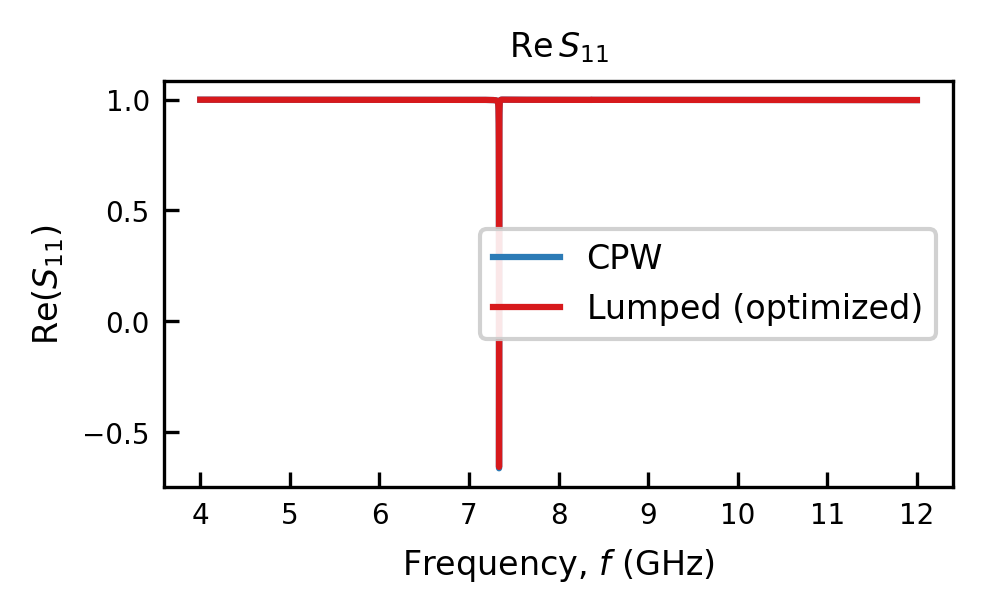

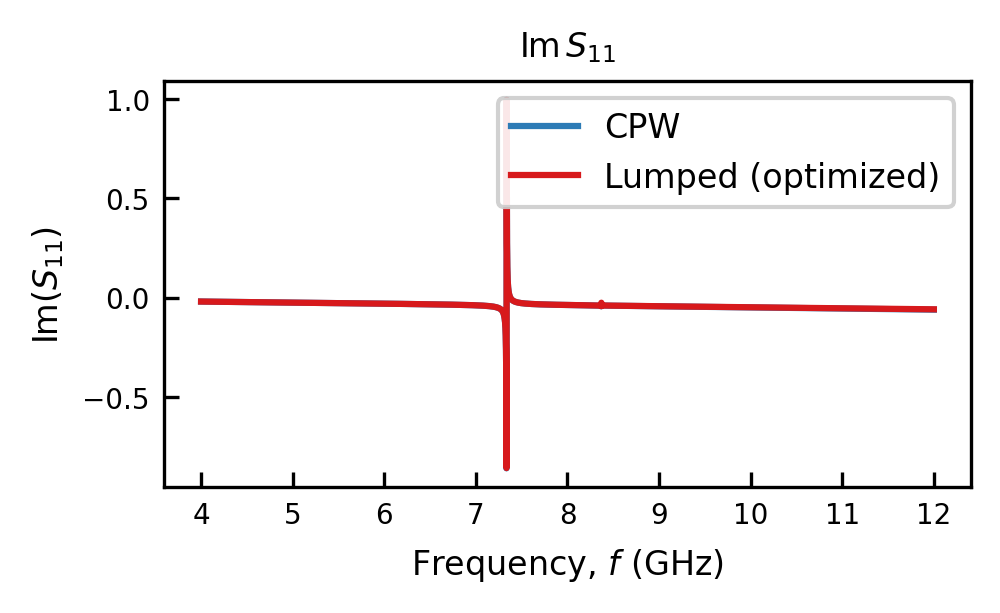

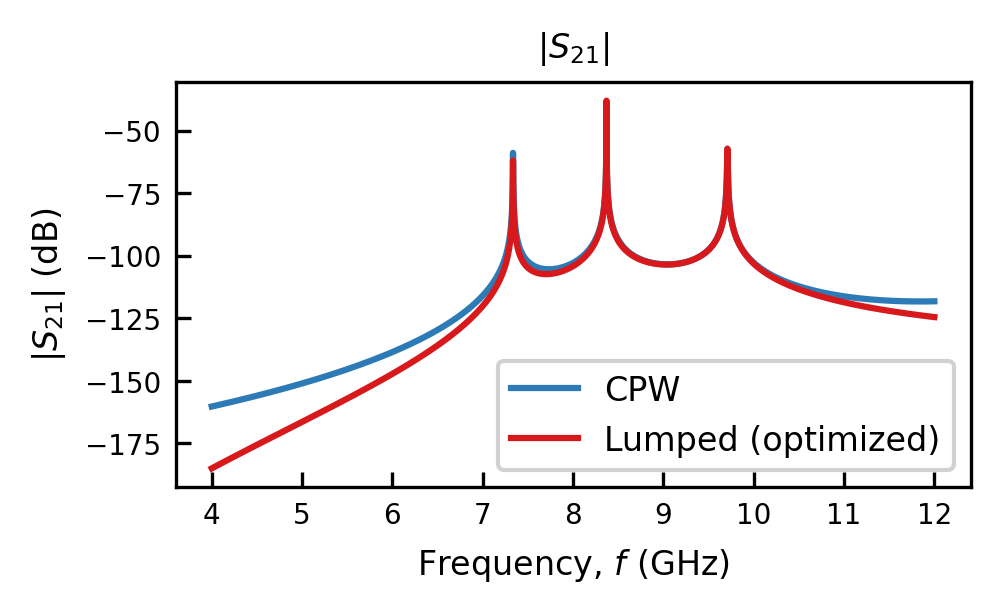

(<Figure size 1012.5x625.759 with 1 Axes>,
 <Axes: title={'center': '$|S_{21}|$'}, xlabel='Frequency, $f$ (GHz)', ylabel='$|S_{21}|$ (dB)'>)

In [9]:
chain_lc = resonator_chain_network_2port(
    freq, segments_lc, Ccs, Ctogs=None, cpw_params=cpw, Z0=Z0,
)

nets = {"CPW": chain_cpw, "Lumped (optimized)": chain_lc}

# The comparison the reduction is judged on: Re/Im of S11, lumped vs CPW.
plot_all_models(nets, m=0, n=0, quantity="re", title=r"$\mathrm{Re}\,S_{11}$")
plot_all_models(nets, m=0, n=0, quantity="im", title=r"$\mathrm{Im}\,S_{11}$")
plot_all_models(nets, m=1, n=0, quantity="db", title=r"$|S_{21}|$")


### 3b. Per-mode frequency agreement

 between the lumped chain and the CPW ground truth.
Now that they are both built, we can find agreement (or lack thereof) between the lumped and CPW chains.

To do so, we locate each mode on the coarse grid, then circle-fit both chains on a dense
window around it for sub-MHz resolution.

In [10]:

mode_guess = np.sort(resonances_from_s_max(chain_cpw, m=1, n=0))

def mode_f0(segments, Ctogs, f_guess):
    win = rf.Frequency(f_guess - 0.15e9, f_guess + 0.15e9, 40_001, unit="Hz")
    net = resonator_chain_network_2port(win, segments, Ccs, Ctogs=Ctogs,
                                        cpw_params=cpw, Z0=Z0)
    f0, _ = circle_fit_f0_kappa(net, 0, 0)
    return f0

rows_cmp = []
for j, fg in enumerate(mode_guess, start=1):
    f_cpw = mode_f0(segments_cpw, Ctogs, fg)
    f_lc = mode_f0(segments_lc, None, fg)
    rows_cmp.append({
        "mode": j,
        "CPW_GHz": f_cpw / 1e9,
        "Lumped_GHz": f_lc / 1e9,
        "error_MHz": (f_lc - f_cpw) / 1e6,
        "error_%": 100.0 * (f_lc - f_cpw) / f_cpw,
    })

compare = pd.DataFrame(rows_cmp)
compare


,mode,CPW_GHz,Lumped_GHz,error_MHz,error_%
0,1,7.335346,7.335350,0.003762,0.000051
1,2,8.369481,8.369993,0.511327,0.006109
2,3,9.705619,9.705852,0.233740,0.002408



For this network, fitting each resonator in isolation with the Optimized
LOM and stitching the pieces back together reproduces the full CPW chain
closely. The mode frequencies line up and the $S_{11}$ lineshape overlays the
ground truth. 

The main approximation we made was that each subgroup was fit against $50\,\Omega$ ports, not against its neighbouring
resonators. 


### 3c. Draw the final LC chain schematic

Finally, redraw the network in its lumped form — the **same schematic builder**,
now fed `LC` segments, so the CPW lines are replaced by parallel-`LC` tanks
showing the fitted $L$ and $C$.


In [11]:
schematic_lc = resonator_chain_schematic_2port(
    segments_lc, Ccs, Ctogs=None,
    cpw_params=cpw, freq=freq, Z0=Z0,
    annotations={"model": "optimized", "resonators": len(lengths)},
)
schematic_lc.save_svg(figdir / "chain_lc.svg")
schematic_lc.save_html(figdir / "chain_lc.html")
schematic_lc


Schematic(meta={'title': '', 'description': '', 'source': 'simpleLOMs.networks.chain.resonator_chain_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'res1', 'label': 'resonator 1'}, {'id': 'res2', 'label': 'resonator 2'}, {'id': 'res3', 'label': 'resonator 3'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='Cc1', type='cap', label='C_{c1}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='LC1', type='lc', label='LC 1', value='L = 640.24 pH\nC = 721.10 fF', ports=['a', 'gnd'], group='res1', orient='shunt', props={'L': 6.402449689722727e-10, 'C': 7.210973077537339e-13}), Component(id='Cc2', type='cap', label='C_{c2}', value='6.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 6e-15}), Component(id='LC2', type='lc', label='LC 2', value='L = 560.36 pH\nC = 633.29 fF', ports=['a', 'gnd'], group='res2', orient='shunt', props={'L': 5.603621849330044e-10, 'C': 6.33292138423551e-13}), Component(id='Cc3', type='cap', label='C_{c3}', value='6.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 6e-15}), Component(id='LC3', type='lc', label='LC 3', value='L = 483.52 pH\nC = 541.99 fF', ports=['a', 'gnd'], group='res3', orient='shunt', props={'L': 4.835166317342839e-10, 'C': 5.419940935964193e-13}), Component(id='Cc4', type='cap', label='C_{c4}', value='8.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 8e-15}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'LC1.a']), Net(id='n3', ports=['LC1.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'Cc2.a']), Net(id='n5', ports=['Cc2.b', 'LC2.a']), Net(id='n6', ports=['LC2.gnd', 'GND']), Net(id='n7', ports=['Cc2.b', 'Cc3.a']), Net(id='n8', ports=['Cc3.b', 'LC3.a']), Net(id='n9', ports=['LC3.gnd', 'GND']), Net(id='n10', ports=['Cc3.b', 'Cc4.a']), Net(id='n11', ports=['Cc4.b', 'P2.in'])], annotations={'model': 'optimized', 'resonators': 3})